# مشروع تحليل بيانات سوق العقارات السكني في المملكة العربية السعودية
## الجزء 2: التحليل الاستكشافي الكامل (EDA) والنموذج التنبؤي الأولي

**المصدر:** الرقم القياسي لأسعار العقارات (REPI) — الهيئة العامة للإحصاء، الربع الثاني 2026 (سنة الأساس 2023=100)
**المدخلات:** `repi_by_type_clean.csv`, `repi_by_region_clean.csv` (نواتج الجزء 1)

**محاور هذا الـ Notebook:**
1. ترتيب المناطق حسب أداء المؤشر (2021Q1 → 2026Q2)
2. مقارنة أنواع العقار السكني (أراضٍ سكنية / فلل / شقق)
3. تحليل الموسمية الربعية
4. نموذج تنبؤي أولي (Baseline) للمؤشر العام


## 1. استيراد المكتبات وتحميل البيانات النظيفة

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df_type = pd.read_csv('repi_by_type_clean.csv')
df_region = pd.read_csv('repi_by_region_clean.csv')

# ترتيب زمني موثوق للأرباع (لضمان ترتيب المحاور الزمنية بشكل صحيح في كل الرسوم)
quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
for d in (df_type, df_region):
    d['q_num'] = d['quarter_code'].map(quarter_order)
    d.sort_values(['year', 'q_num'], inplace=True)

print(df_type.shape, df_region.shape)
print('الأرباع المتاحة:', df_type['quarter_period'].nunique())


(264, 9) (308, 9)
الأرباع المتاحة: 22


## 2. ترتيب المناطق حسب أداء المؤشر

نستبعد "عام (المملكة)" من الترتيب لأنه ليس منطقة بل هو المؤشر الكلي المرجعي، ونحتفظ به فقط للمقارنة.

In [2]:
import pandas as pd
import numpy as np

first_q = df_region['quarter_period'].min()
last_q = df_region['quarter_period'].max()

first_vals = df_region[df_region['quarter_period'] == first_q].set_index('region_ar')['index_value']
last_vals = df_region[df_region['quarter_period'] == last_q].set_index('region_ar')['index_value']

region_growth = pd.DataFrame({
    f'index_{first_q}': first_vals,
    f'index_{last_q}': last_vals,
})
region_growth['total_growth_pct'] = ((region_growth[f'index_{last_q}'] / region_growth[f'index_{first_q}']) - 1) * 100
region_growth = region_growth.sort_values('total_growth_pct', ascending=False)

print(f"إجمالي النمو التراكمي من {first_q} إلى {last_q}:")
region_growth.round(2)


إجمالي النمو التراكمي من 2021Q1 إلى 2026Q2:


,index_2021Q1,index_2026Q2,total_growth_pct
region_ar,,,
الرياض,74.40,115.98,55.89
عام (المملكة),81.37,106.34,30.69
مكة المكرمة,86.67,102.43,18.18
الجوف,90.56,107.02,18.18
نجران,86.49,100.11,15.75
الحدود الشمالية,91.89,103.86,13.03
تبوك,91.34,102.63,12.36
المنطقة الشرقية,89.34,95.73,7.15
جازان,95.42,98.79,3.53


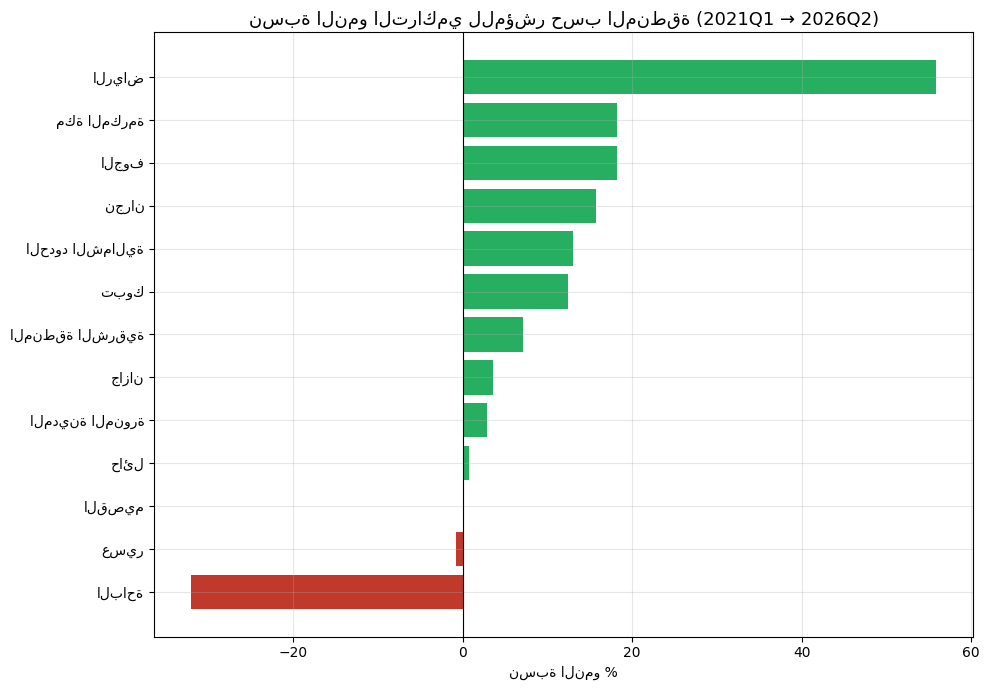

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ranking = region_growth.drop(index='عام (المملكة)', errors='ignore').sort_values('total_growth_pct')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in ranking['total_growth_pct']]
ax.barh(ranking.index, ranking['total_growth_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'نسبة النمو التراكمي للمؤشر حسب المنطقة ({first_q} → {last_q})', fontsize=13)
ax.set_xlabel('نسبة النمو %')
plt.tight_layout()
plt.savefig('region_ranking.png', dpi=150)
plt.show()


### أعلى وأقل 3 مناطق أداءً

In [4]:
import pandas as pd

top3 = ranking.sort_values('total_growth_pct', ascending=False).head(3)
bottom3 = ranking.sort_values('total_growth_pct', ascending=False).tail(3)

print("🔝 أعلى 3 مناطق نمواً:")
print(top3[['total_growth_pct']].round(2))
print("\n🔻 أقل 3 مناطق نمواً:")
print(bottom3[['total_growth_pct']].round(2))


🔝 أعلى 3 مناطق نمواً:
             total_growth_pct
region_ar                    
الرياض                  55.89
مكة المكرمة             18.18
الجوف                   18.18

🔻 أقل 3 مناطق نمواً:
           total_growth_pct
region_ar                  
القصيم                 0.12
عسير                  -0.79
الباحة               -32.05


## 3. مقارنة أنواع العقار السكني (أراضٍ سكنية / فلل / شقق)

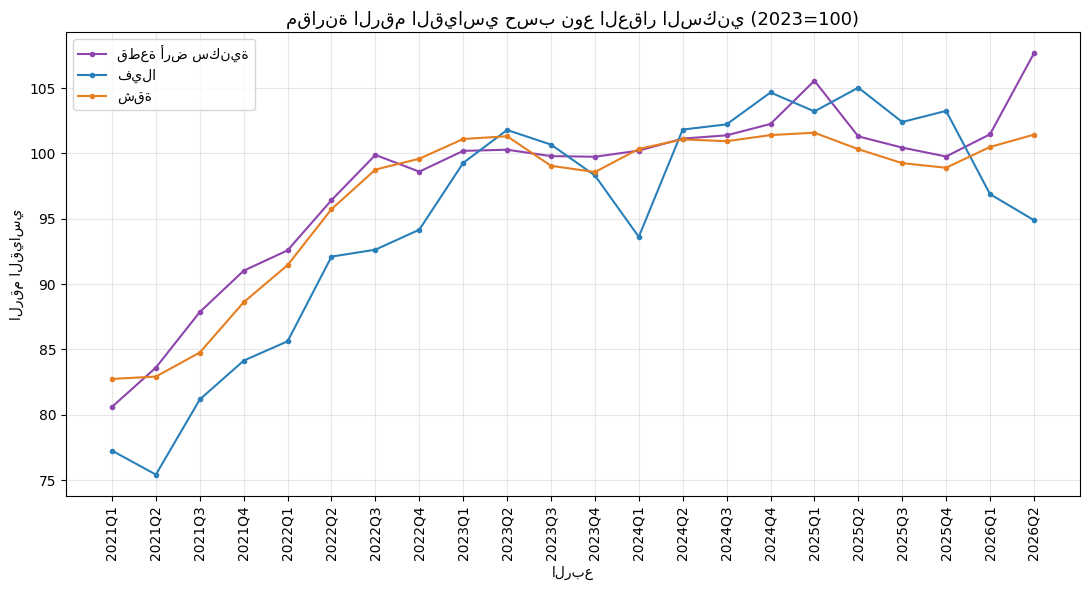

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

types_of_interest = ['قطعة أرض سكنية', 'فيلا', 'شقة']
colors_map = {'قطعة أرض سكنية': '#8e44ad', 'فيلا': '#2980b9', 'شقة': '#e67e22'}

fig, ax = plt.subplots()
for t in types_of_interest:
    sub = df_type[df_type['category_ar'] == t].sort_values(['year', 'q_num'])
    ax.plot(sub['quarter_period'], sub['index_value'], marker='o', markersize=3,
            label=t, color=colors_map[t])

ax.set_title('مقارنة الرقم القياسي حسب نوع العقار السكني (2023=100)', fontsize=13)
ax.set_xlabel('الربع')
ax.set_ylabel('الرقم القياسي')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig('property_type_comparison.png', dpi=150)
plt.show()


In [6]:
import pandas as pd

type_growth_summary = []
for t in types_of_interest:
    sub = df_type[df_type['category_ar'] == t].sort_values(['year', 'q_num'])
    start_val = sub.iloc[0]['index_value']
    end_val = sub.iloc[-1]['index_value']
    volatility = sub['qoq_change_pct'].std()
    type_growth_summary.append({
        'النوع': t,
        'growth_total_pct': round((end_val / start_val - 1) * 100, 2),
        'latest_yoy_pct': round(sub.iloc[-1]['yoy_change_pct'], 2),
        'volatility_qoq_std': round(volatility, 2),
    })

pd.DataFrame(type_growth_summary)


,النوع,growth_total_pct,latest_yoy_pct,volatility_qoq_std
0,قطعة أرض سكنية,33.56,6.3,2.42
1,فيلا,22.83,-9.7,4.01
2,شقة,22.59,1.1,1.81


## 4. تحليل الموسمية الربعية

هل توجد أرباع معينة (Q1/Q2/Q3/Q4) يتكرر فيها نمط ارتفاع أو انخفاض في المؤشر عبر السنوات؟ نحسب متوسط التغيّر الربعي (QoQ%) لكل موقع ربع، لكل من المؤشر العام والسكني الإجمالي.

quarter_code     Q1    Q2   Q3    Q4
category_ar                         
إجمالي السكني  1.28  1.72  1.2  0.70
عام            1.00  1.80  1.3  0.98


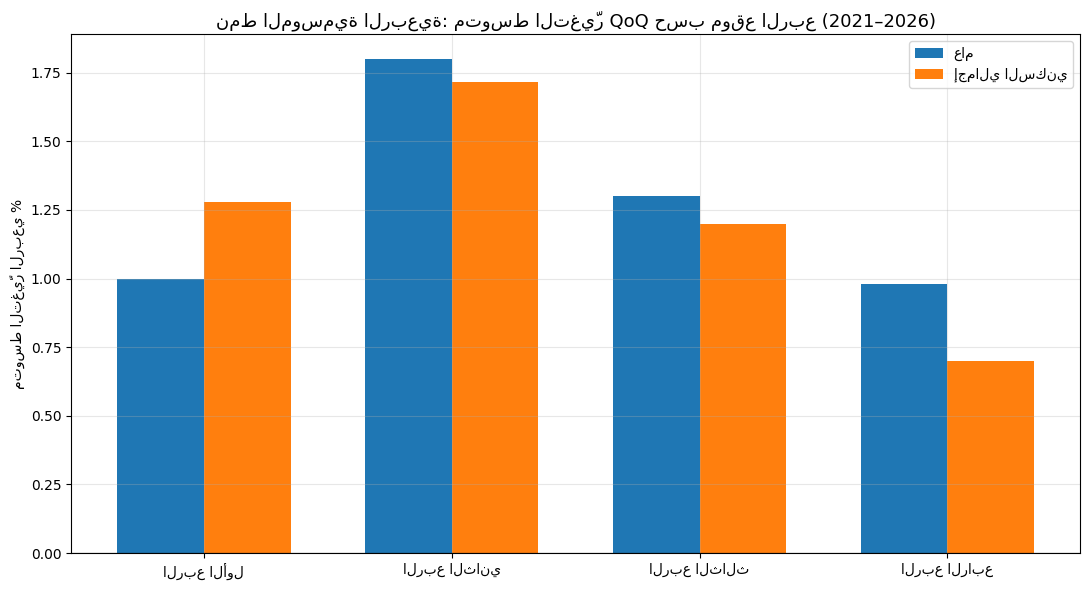

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seasonal_categories = ['عام', 'إجمالي السكني']
seasonal_summary = (
    df_type[df_type['category_ar'].isin(seasonal_categories)]
    .groupby(['category_ar', 'quarter_code'])['qoq_change_pct']
    .mean()
    .unstack('quarter_code')[['Q1', 'Q2', 'Q3', 'Q4']]
)
print(seasonal_summary.round(2))

fig, ax = plt.subplots()
x = np.arange(4)
width = 0.35
for i, cat in enumerate(seasonal_categories):
    ax.bar(x + i * width, seasonal_summary.loc[cat], width, label=cat)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(['الربع الأول', 'الربع الثاني', 'الربع الثالث', 'الربع الرابع'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('متوسط التغيّر الربعي %')
ax.set_title('نمط الموسمية الربعية: متوسط التغيّر QoQ حسب موقع الربع (2021–2026)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()


**ملاحظة على العينة:** التغطية الزمنية المتاحة (2021–2026) تعني أن كل موقع ربع (Q1، Q2، إلخ) مبني على 5–6 مشاهدات سنوية فقط. هذا كافٍ لرصد **نمط أولي** لكنه لا يكفي إحصائياً لتأكيد موسمية قوية بثقة عالية — يُفضّل التعامل مع النتيجة كإشارة استكشافية وليست استنتاجاً قاطعاً.

## 5. نموذج تنبؤي أولي (Baseline Forecast)

نستخدم المؤشر العام كسلسلة زمنية، مع نموذجين بسيطين للمقارنة:
- **اتجاه خطي (Linear Trend)** كخط أساس بسيط
- **التمهيد الأسي البسيط مع اتجاه (Holt's Linear Trend / Exponential Smoothing)** كنموذج أكثر واقعية لسلاسل زمنية اقتصادية قصيرة

⚠️ **تنبيه منهجي:** هذا نموذج أولي (Baseline) بعينة صغيرة نسبياً (22 مشاهدة ربعية) ولأغراض تعلّم منهجية التنبؤ فقط. لا ينبغي استخدام نتائجه كأساس لقرار استثماري فعلي دون نمذجة أكثر تعمقاً (ARIMA/SARIMA مع اختبار الموسمية الإحصائية، بيانات أطول، ومتغيرات اقتصادية مساندة).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

general = df_type[df_type['category_ar'] == 'عام'].sort_values(['year', 'q_num']).reset_index(drop=True)
series = general.set_index(pd.PeriodIndex(general['quarter_period'].str.replace(r'(\d{4})(Q\d)', r'\1\2', regex=True), freq='Q'))['index_value']

n_forecast = 4  # أربعة أرباع قادمة

# --- نموذج 1: اتجاه خطي بسيط ---
x = np.arange(len(series))
coeffs = np.polyfit(x, series.values, deg=1)
linear_fit = np.poly1d(coeffs)
future_x = np.arange(len(series), len(series) + n_forecast)
linear_forecast = linear_fit(future_x)

# --- نموذج 2: Holt's Linear Trend (تمهيد أسي مع اتجاه) ---
hw_model = ExponentialSmoothing(series.values, trend='add', seasonal=None, initialization_method='estimated')
hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(n_forecast)

future_periods = pd.period_range(series.index[-1] + 1, periods=n_forecast, freq='Q')

print("توقعات الأرباع القادمة:")
forecast_table = pd.DataFrame({
    'الربع': [str(p) for p in future_periods],
    'اتجاه_خطي': linear_forecast.round(2),
    'تمهيد_أسي_Holt': hw_forecast.round(2),
})
forecast_table


توقعات الأرباع القادمة:


,الربع,اتجاه_خطي,تمهيد_أسي_Holt
0,2026Q3,109.94,107.15
1,2026Q4,110.98,107.96
2,2027Q1,112.01,108.77
3,2027Q2,113.05,109.58


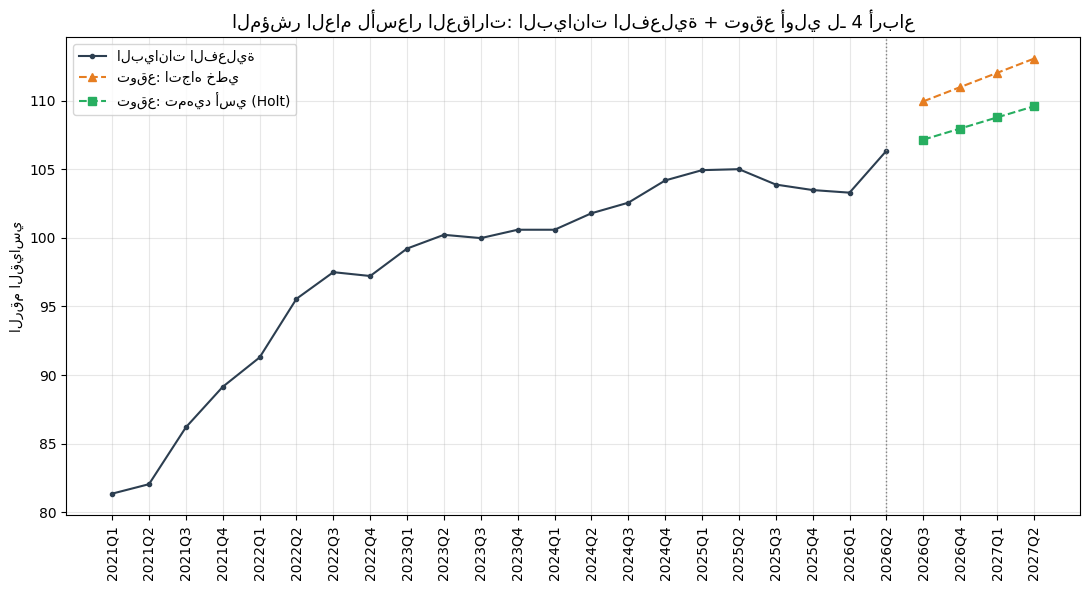

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(range(len(series)), series.values, marker='o', markersize=3, label='البيانات الفعلية', color='#2c3e50')
ax.plot(future_x, linear_forecast, marker='^', linestyle='--', label='توقع: اتجاه خطي', color='#e67e22')
ax.plot(future_x, hw_forecast, marker='s', linestyle='--', label='توقع: تمهيد أسي (Holt)', color='#27ae60')
ax.axvline(len(series) - 1, color='gray', linestyle=':', linewidth=1)

all_labels = list(series.index.astype(str)) + [str(p) for p in future_periods]
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=90)
ax.set_title('المؤشر العام لأسعار العقارات: البيانات الفعلية + توقع أولي لـ 4 أرباع', fontsize=13)
ax.set_ylabel('الرقم القياسي')
ax.legend()
plt.tight_layout()
plt.savefig('forecast_general_index.png', dpi=150)
plt.show()


---
## خلاصة الجزء 2

- **ترتيب المناطق:** تم استخراج ترتيب واضح للمناطق حسب النمو التراكمي في المؤشر (2021Q1–2026Q2)، مع تحديد أعلى وأقل 3 مناطق أداءً.
- **أنواع العقار:** تمت مقارنة الأراضي السكنية والفلل والشقق من حيث النمو التراكمي والتقلب (volatility).
- **الموسمية:** رُصد نمط أولي لمتوسط التغيّر الربعي حسب موقع الربع، مع تنبيه بمحدودية حجم العينة.
- **التنبؤ:** نموذجان أوليان (اتجاه خطي، وتمهيد أسي Holt) لأربعة أرباع قادمة، كخط أساس فقط.

### الخطوة التالية (الجزء 3 المقترح)
- بناء تقرير/لوحة نهائية (Power BI أو Plotly Dash) تجمع كل هذه النتائج
- توثيق المشروع على GitHub بصيغة جاهزة للـ portfolio
